In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.models import Model

2026-05-16 14:29:24.262542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778941764.485929      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778941764.543271      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778941765.016501      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778941765.016557      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778941765.016561      57 computation_placer.cc:177] computation placer alr

In [2]:
base_dir = '../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir = base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

# ============================================================
# LOAD IMAGE PATHS
# ============================================================

train_pn = [train_pneumonia_dir+i for i in os.listdir(train_pneumonia_dir)]
train_normal = [train_normal_dir+i for i in os.listdir(train_normal_dir)]

test_pn = [test_pneumonia_dir+i for i in os.listdir(test_pneumonia_dir)]
test_normal = [test_normal_dir+i for i in os.listdir(test_normal_dir)]

train_imgs = train_pn + train_normal
test_imgs = test_pn + test_normal

In [3]:
IMG_SIZE = 224

def prepare_data(img_list):

    X = []
    y = []

    for img_path in tqdm(img_list):

        try:

            img = cv2.imread(img_path)

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            img = preprocess_input(img)

            X.append(img)

            if 'PNEUMONIA' in img_path:
                y.append(1)
            else:
                y.append(0)

        except:
            pass

    return np.array(X), np.array(y)

In [4]:
print("\nLoading Training Data...")
X_train, y_train = prepare_data(train_imgs)

print("\nLoading Testing Data...")
X_test, y_test = prepare_data(test_imgs)

print("\nTrain Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)



Loading Training Data...


100%|██████████| 5216/5216 [01:43<00:00, 50.44it/s]



Loading Testing Data...


100%|██████████| 624/624 [00:11<00:00, 53.96it/s]



Train Shape : (5216, 224, 224, 3)
Test Shape  : (624, 224, 224, 3)


In [5]:
# LOAD VGG16 MODEL
# ============================================================

base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Feature extractor
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.output
)


I0000 00:00:1778941908.378978      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# EXTRACT FEATURES


print("\nExtracting VGG16 Features...")

train_features = feature_extractor.predict(X_train)

test_features = feature_extractor.predict(X_test)

print("\nFeature Shape :", train_features.shape)


# FLATTEN FEATURES


X_train_features = train_features.reshape(
    train_features.shape[0],
    -1
)

X_test_features = test_features.reshape(
    test_features.shape[0],
    -1
)

print("\nFlattened Shape :", X_train_features.shape)


Extracting VGG16 Features...


I0000 00:00:1778941918.437922     133 service.cc:152] XLA service 0x7a07d0006460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778941918.437979     133 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778941918.620313     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/163 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step

I0000 00:00:1778941926.334796     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step

Feature Shape : (5216, 7, 7, 512)

Flattened Shape : (5216, 25088)


In [7]:
xgb_model = XGBClassifier(

    n_estimators=100,

    max_depth=6,

    learning_rate=0.1,

    objective='binary:logistic',

    eval_metric='logloss',

    random_state=42
)

In [8]:
print("\nTraining XGBoost...\n")

xgb_model.fit(X_train_features, y_train)


y_pred = xgb_model.predict(X_test_features)


Training XGBoost...



In [9]:
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)

specificity = TN / (TN + FP)


In [10]:
print("\n===================================================")
print("    CHEST X-RAY VGG16 + XGBOOST RESULTS")
print("===================================================\n")

print(f"Accuracy      : {accuracy*100:.2f}%")

print(f"F1-Score      : {f1:.4f}")

print(f"Sensitivity   : {sensitivity:.4f}")

print(f"Specificity   : {specificity:.4f}")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


    CHEST X-RAY VGG16 + XGBOOST RESULTS

Accuracy      : 76.92%
F1-Score      : 0.8435
Sensitivity   : 0.9949
Specificity   : 0.3932

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.39      0.56       234
           1       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.86      0.69      0.70       624
weighted avg       0.82      0.77      0.74       624



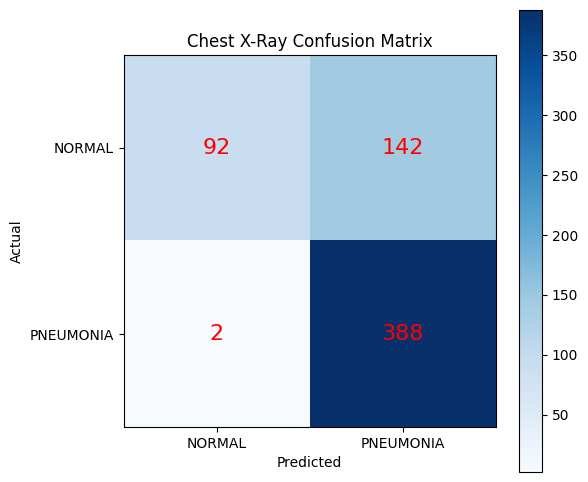

In [11]:
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap='Blues')

plt.title("Chest X-Ray Confusion Matrix")

plt.xticks([0,1], ['NORMAL','PNEUMONIA'])

plt.yticks([0,1], ['NORMAL','PNEUMONIA'])

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i,j],
            ha='center',
            va='center',
            color='red',
            fontsize=16
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()